In [10]:
import cv2
import os
import matplotlib.pyplot as plt
import kagglehub
import tensorflow as tf
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

In [11]:
!pip install opencv-python
!pip install tqdm
!pip install scikit-image

Using Colab cache for faster access to the 'flowers-dataset' dataset.
Path to dataset files: /kaggle/input/flowers-dataset
Found actual categories: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Processing category: daisy (label: 0) in train


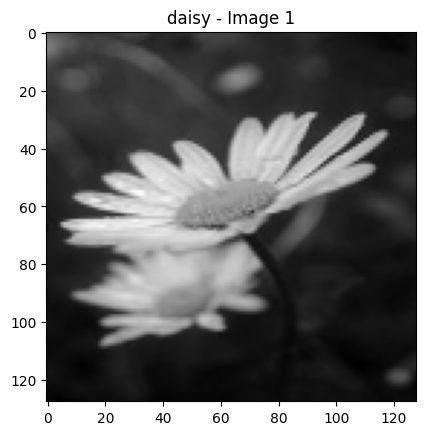

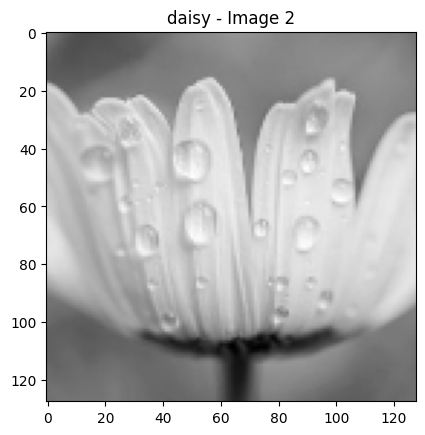

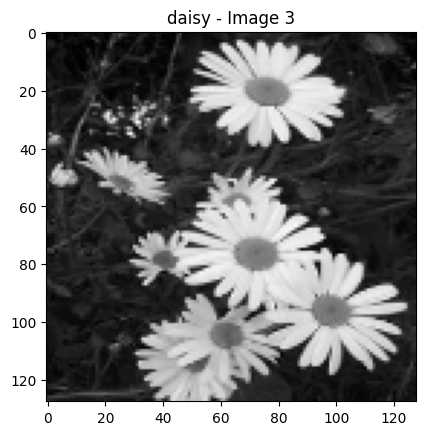

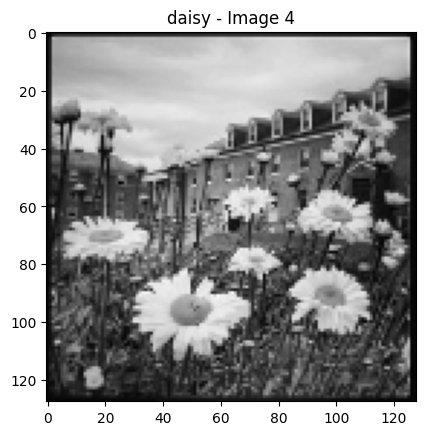

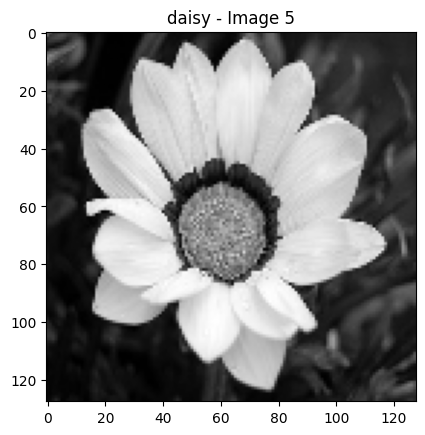

Processing category: dandelion (label: 1) in train
Processing category: rose (label: 2) in train
Processing category: sunflower (label: 3) in train
Processing category: tulip (label: 4) in train
Total images processed: 2746
First 5 flattened image array lengths: [16384, 16384, 16384, 16384, 16384]


In [12]:
datadir = kagglehub.dataset_download("imsparsh/flowers-dataset")
print("Path to dataset files:", datadir)

x = []
y = []
IMG_SIZE = 128

# Correctly identify categories from the 'train' subdirectory
train_dir = os.path.join(datadir, 'train')
# Filter out any non-directory entries and get actual flower categories
category_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print(f"Found actual categories: {category_names}")

c = 0
# Iterate through both 'train' and 'test' directories to load images
for base_folder in ['train', 'test']:
    current_base_path = os.path.join(datadir, base_folder)
    if not os.path.isdir(current_base_path):
        continue

    for class_idx, flower_type in enumerate(category_names):
        folder_path = os.path.join(current_base_path, flower_type)

        if not os.path.isdir(folder_path):
            # This can happen if a category exists in train but not in test, or vice versa
            print(f"Warning: Category folder not found: {folder_path}. Skipping.")
            continue
        print(f"Processing category: {flower_type} (label: {class_idx}) in {base_folder}")

        for img_filename in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_filename)

            # Ensure it's an image file before processing (optional, but good practice)
            if not img_filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                continue

            img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img_array is None:
                print(f"Warning: Could not load image {img_path}. Skipping.")
                continue

            resized_img_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
            x.append(resized_img_array.flatten())
            y.append(class_idx)

            if c < 5:
                plt.imshow(resized_img_array, cmap='gray')
                plt.title(f"{flower_type} - Image {c+1}")
                plt.show()

            c = c + 1

print("Total images processed:", c)
print(f"First 5 flattened image array lengths: {[len(img_data) for img_data in x[:5]]}") # Verify lengths

In [13]:
x = np.array(x, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print(f"Shape of X (image data): {x.shape}")   # (n, 224, 224, 3)
print(f"Shape of Y (labels): {y.shape}")

# Convert labels to one-hot vectors for softmax classification
y_cat = to_categorical(y, num_classes=len(category_names))
print(f"Shape of Y one-hot: {y_cat.shape}")

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y_cat, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape :", x_test.shape, y_test.shape)

Shape of X (image data): (2746, 16384)
Shape of Y (labels): (2746,)
Shape of Y one-hot: (2746, 5)
Train shape: (2196, 16384) (2196, 5)
Test shape : (550, 16384) (550, 5)


In [14]:
# Reshape flattened grayscale images to (IMG_SIZE, IMG_SIZE, 1)
x_train_reshaped = x_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
x_test_reshaped = x_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

# ResNet50 expects 3-channel input
x_train_rgb = np.repeat(x_train_reshaped, 3, axis=-1)
x_test_rgb = np.repeat(x_test_reshaped, 3, axis=-1)

# Preprocess for ResNet
x_train_p = preprocess_input(x_train_rgb)
x_test_p = preprocess_input(x_test_rgb)

# Build ResNet model
base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model at first
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),   # hidden layer
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),     # extra hidden layer
    layers.Dropout(0.3),
    layers.Dense(len(category_names), activation='softmax')
])

# Optimizer
opt = optimizers.Adam(learning_rate=1e-4)

# Evaluation metrics
model.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

model.summary()

early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

history = model.fit(
    x_train_p, y_train,
    validation_data=(x_test_p, y_test),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,858,565 (91.01 MB)

 Trainable params: 270,853 (1.03 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.3388 - loss: 1.8824 - precision: 0.3827 - recall: 0.2222 - val_accuracy: 0.6000 - val_loss: 1.1646 - val_precision: 0.7834 - val_recall: 0.3091 - learning_rate: 1.0000e-04
Epoch 2/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.4859 - loss: 1.2849 - precision: 0.6158 - recall: 0.3379 - val_accuracy: 0.6727 - val_loss: 0.9882 - val_precision: 0.8266 - val_recall: 0.4073 - learning_rate: 1.0000e-04
Epoch 3/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.5642 - loss: 1.1264 - precision: 0.6915 - recall: 0.4144 - val_accuracy: 0.7000 - val_loss: 0.8970 - val_precision: 0.8333 - val_recall: 0.4636 - learning_rate: 1.0000e-04
Epoch 4/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.6111 - loss: 0.9853 - precision: 0.7524 - recall: 0.4704 - val_accuracy: 0.7327 - val_loss: 0.8116 - val_precision: 0.8492 - val_recall: 0.5527 - learning_rate: 1.0000e-04
Epoch 5/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - 

In [15]:
# Evaluate on test set
test_loss, test_acc, test_precision, test_recall = model.evaluate(x_test_p, y_test, verbose=0)
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")

# Predictions
y_prob = model.predict(x_test_p)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Extra evaluation metrics
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=category_names))

print("Macro F1 Score :", f1_score(y_true, y_pred, average='macro'))
print("Macro Precision:", precision_score(y_true, y_pred, average='macro'))
print("Macro Recall   :", recall_score(y_true, y_pred, average='macro'))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Test Loss      : 0.6309
Test Accuracy  : 0.7855
Test Precision : 0.8523
Test Recall    : 0.6927
18/18 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step

Classification Report:
              precision    recall  f1-score   support

       daisy       0.73      0.72      0.72       100
   dandelion       0.89      0.82      0.85       129
        rose       0.74      0.86      0.79       100
   sunflower       0.78      0.68      0.72        99
       tulip       0.78      0.83      0.80       122

    accuracy                           0.79       550
   macro avg       0.78      0.78      0.78       550
weighted avg       0.79      0.79      0.79       550

Macro F1 Score : 0.7800377458117257
Macro Precision: 0.783017453742488
Macro Recall   : 0.7812683911166565

Confusion Matrix:
[[ 72   5   9  11   3]
 [ 14 106   1   2   6]
 [  1   1  86   1  11]
 [ 10   7   7  67   8]
 [  2   0  14   5 101]]


In [18]:
model.save("flower_image_model.h5")